# Contando possibilidades

No dia a dia, muitas situações envolvem escolher entre diferentes combinações possíveis. Em alguns casos, conseguimos listar todas as possibilidades com facilidade.

Mas será que isso sempre funciona? Vamos começar com um exemplo simples.

Você vai fazer uma refeição em uma lanchonete e tem 2 opções de lanches salgados (🍔 Hambúrguer e 🍕 Pizza) e 3 opções de sobremesas (🍦 Sorvete, 🍩 Donut e 🎂 Bolo), quantos cardápios diferentes você consegue montar?

**a)** Liste todos os cardápios possíveis.

In [1]:
%%html
<p><b>Sua lista:</b></p>
<textarea style="width: 100%; height: 100px; border: 1px solid #ccc; border-radius: 4px;"></textarea>

**b)** Quantos cardápios diferentes você encontrou?

Após listar as combinações, observe sua resposta.

**c)** Sua lista está organizada de alguma forma?

**d)** Existe o risco de você ter esquecido alguma combinação ou repetido outra?

Quando o número de possibilidades é pequeno, listar pode parecer suficiente. No entanto, sem organização, fica fácil se confundir, repetir casos ou deixar possibilidades de fora.

Uma maneira de evitar esse problema é organizar as combinações de forma sistemática.

**e)** Reorganize sua lista agrupando os cardápios de acordo com cada opção de lanche salgado.

In [2]:
%%html
<p><b>Sua lista organizada:</b></p>
<textarea style="width: 100%; height: 100px; border: 1px solid #ccc; border-radius: 4px;"></textarea>

```{admonition} Veja a lista organizada
:class: dropdown

* 🍔🍦 (Hambúrguer com Sorvete)
* 🍔🍩 (Hambúrguer com Donut)
* 🍔🎂 (Hambúrguer com Bolo)
* 🍕🍦 (Pizza com Sorvete)
* 🍕🍩 (Pizza com Donut)
* 🍕🎂 (Pizza com Bolo)

**Aumentando o desafio**

Até agora, foi fácil, certo? Mas e se as opções aumentassem? Imagine que você está em uma lanchonete que oferece 5 lanches salgados e 6 sobremesas.

Você conseguiria listar todas essas combinações agora?

Quanto tempo levaria para escrever cada uma delas no caderno?

Seria fácil se perder no meio de tantas opções?

À medida que o número de escolhas cresce, criar uma lista completa se torna uma tarefa cansativa. É aqui que a tecnologia pode trabalhar a nosso favor!

Em vez de escrevermos um por um, vamos usar o nosso simulador de cardápios para descobrir o número de combinações.
Arraste os controles deslizantes para escolher as quantidades de lanches salgados e sobremesas.

In [2]:
import json
from IPython.display import HTML, display

# 1. Você continua gerenciando tudo pelo Python!
# Fica super fácil adicionar ou remover itens no futuro.
lanches = [
    ["🍔", "Hambúrguer"], ["🍕", "Pizza"], ["🌭", "Cachorro-Quente"], 
    ["🥪", "Sanduíche"], ["🌮", "Taco"], ["🍟", "Batata Frita"], 
    ["🍙", "Bolinho de Arroz"], ["🍝", "Macarrão"]
]

sobremesas = [
    ["🍦", "Sorvete"], ["🍧", "Raspadinha"], ["🍩", "Donut"], 
    ["🎂", "Bolo"], ["🍰", "Fatia de Bolo"], ["🧁", "Cupcake"], 
    ["🥞", "Panqueca"], ["🍫", "Chocolate"], ["🍪", "Cookie"]
]

# 2. O Python "traduz" essas listas para um formato que o navegador do aluno entende
lanches_json = json.dumps(lanches)
sobremesas_json = json.dumps(sobremesas)

# 3. O Python monta a interface visual que vai morar dentro do seu Jupyter Book
codigo_interativo = f"""
<div style="font-family: system-ui, sans-serif; max-width: 600px; margin: 20px auto; padding: 20px; border: 1px solid #e1e4e6; border-radius: 8px; background-color: #f8f9fa;">
    <h3 style="margin-top: 0; color: #24292e;">🍽️ Simulador de Cardápios</h3>
    
    <div style="margin-bottom: 15px;">
        <label style="display: inline-block; width: 180px; font-weight: bold;">Lanches Salgados: <span id="valLanches">2</span></label>
        <input type="range" id="slideLanches" min="1" max="8" value="2" style="width: 200px; vertical-align: middle;">
    </div>
    
    <div style="margin-bottom: 20px;">
        <label style="display: inline-block; width: 180px; font-weight: bold;">Sobremesas: <span id="valSobremesas">3</span></label>
        <input type="range" id="slideSobremesas" min="1" max="9" value="3" style="width: 200px; vertical-align: middle;">
    </div>
    
    <div id="calculoHeader" style="font-weight: bold; font-size: 1.1em; color: #0366d6; margin-bottom: 15px; padding-bottom: 10px; border-bottom: 1px solid #e1e4e6;">
        Temos 6 cardápios possíveis.
    </div>
    
    <div id="listaCombinacoes" style="max-height: 250px; overflow-y: auto; background: white; padding: 10px; border: 1px solid #e1e4e6; border-radius: 4px; font-family: monospace; font-size: 0.95em; line-height: 1.6;">
    </div>
</div>

<script>
    // As listas que o Python traduziu entram aqui magicamente!
    const dadosLanches = {lanches_json};
    const dadosSobremesas = {sobremesas_json};

    const sLanches = document.getElementById('slideLanches');
    const sSobremesas = document.getElementById('slideSobremesas');
    const vLanches = document.getElementById('valLanches');
    const vSobremesas = document.getElementById('valSobremesas');
    const header = document.getElementById('calculoHeader');
    const lista = document.getElementById('listaCombinacoes');

    function atualizar() {{
        const nL = parseInt(sLanches.value);
        const nS = parseInt(sSobremesas.value);
        
        vLanches.innerText = nL;
        vSobremesas.innerText = nS;
        header.innerText = `Temos ${{nL * nS}} cardápios possíveis.`;
        
        let htmlStr = "";
        let count = 0;
        
        for (let l = 0; l < nL; l++) {{
            for (let s = 0; s < nS; s++) {{
                count++;
                const countStr = String(count).padStart(2, '0');
                htmlStr += `Cardápio countStr:{{dadosLanches[l][0]}} dadosSobremesas[s][0]−>{{dadosLanches[l][1]}} com ${{dadosSobremesas[s][1]}}<br>`;
            }}
        }}
        lista.innerHTML = htmlStr;
    }}

    sLanches.addEventListener('input', atualizar);
    sSobremesas.addEventListener('input', atualizar);
    atualizar(); // Roda a primeira vez para exibir a lista inicial
</script>
"""

# Exibe o bloco interativo final na célula
display(HTML(codigo_interativo))

**Refletindo sobre o resultado**

Percebeu como a lista ficou extensa? Imagine se fossem 20 lanches e 15 sobremesas! O computador gerou uma lista longa em milésimos de segundo. Mas imagine se você tivesse que fazer isso à mão toda vez que o número de opções aumentasse... seria inviável, não é?

Será que existe uma maneira de descobrir a quantidade total de possibilidades sem precisar escrever o nome de cada uma delas? Vamos voltar ao nosso primeiro exemplo e observar se existe um padrão matemático escondido ali. Podemos organizar essas possibilidades utilizando um diagrama de árvore, que nos ajuda a visualizar todas as combinações possíveis de maneira estruturada.

Vamos fixar em 2 opções de lanches salgados e ver o que acontece quando mudamos a quantidade de opções de sobremesa. Use o controle deslizante para ver o que acontece.

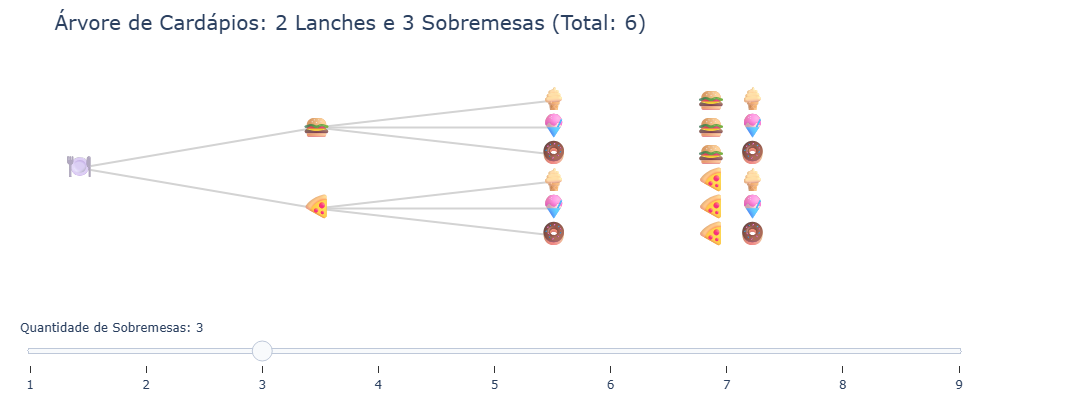

In [3]:
import plotly.graph_objects as go

def criar_arvore_interativa(num_lanches=2):
    # Nossas listas de emojis
    lanches = ["🍔", "🍕", "🌭", "🥪", "🌮", "🍟", "🍙", "🍝"]
    sobremesas = ["🍦", "🍧", "🍩", "🎂", "🍰", "🧁", "🥞", "🍫", "🍪"]
    
    n = min(num_lanches, len(lanches))
    
    # 1. Função interna que calcula as coordenadas da árvore para um número 'm' de sobremesas
    def calcular_dados_da_arvore(m):
        labels = ["🍽️"]
        edges = [(0, k) for k in range(1, n+1)]
        
        for i in range(n): 
            labels.append(lanches[i])
            
        current_index = n + 1
        children = {i: [] for i in range(1, n+1)}
        
        # Lista temporária para guardar a string da combinação final
        resultados_labels = []
        
        for parent in range(1, n+1):
            for j in range(m):
                # Adiciona APENAS a sobremesa no nó da árvore
                labels.append(sobremesas[j]) 
                # Guarda o resultado final para plotar depois
                resultados_labels.append(f"{lanches[parent-1]} {sobremesas[j]}") 
                
                edges.append((parent, current_index))
                children[parent].append(current_index)
                current_index += 1
                
        total_nodes = len(labels)
        total_elements = total_nodes + len(resultados_labels)
        
        Xn, Yn = [0] * total_elements, [0] * total_elements
        total_leaves = n * m
        
        # --- Posicionamento Y Absoluto para não deformar no slider ---
        resultado_idx = total_nodes
        
        # Folhas (Sobremesas) e Resultados Finais
        for i, child in enumerate(range(n+1, total_nodes)):
            # Posição do nó da sobremesa
            Xn[child] = 4
            Yn[child] = -i + (total_leaves - 1)/2.0
            
            # Posição do resultado final (nó fantasma mais à direita)
            Xn[resultado_idx] = 5.5
            Yn[resultado_idx] = Yn[child] # Mantém na mesma linha da sobremesa
            labels.append(resultados_labels[i])
            resultado_idx += 1
            
        # Galhos (Lanches) ficam na média da altura de seus filhos
        for parent in range(1, n+1):
            Xn[parent] = 2
            Yn[parent] = sum(Yn[c] for c in children[parent]) / m
            
        # Raiz (Início) fica na média da altura dos lanches
        Xn[0] = 0
        Yn[0] = sum(Yn[p] for p in range(1, n+1)) / n
        
        # Coordenadas das linhas (as linhas ligam apenas até a sobremesa)
        Xe, Ye = [], []
        for u, v in edges:
            Xe += [Xn[u], Xn[v], None]
            Ye += [Yn[u], Yn[v], None]
            
        # Altura dinâmica da tela e limites do eixo Y
        altura_pixels = max(400, total_leaves * 40 + 150)
        limite_y = [-total_leaves/2 - 1, total_leaves/2 + 1]
        
        return Xe, Ye, Xn, Yn, labels, altura_pixels, limite_y

    # ==========================================
    # 2. Configurando o Plotly com a Árvore Inicial (m=3)
    # ==========================================
    initial_m = 3
    Xe_0, Ye_0, Xn_0, Yn_0, labels_0, height_0, y_range_0 = calcular_dados_da_arvore(initial_m)

    fig = go.Figure()
    
    # Trace 0: Linhas (Galhos)
    fig.add_trace(go.Scatter(
        x=Xe_0, y=Ye_0, mode='lines', 
        line=dict(color='lightgray', width=2), hoverinfo='none'
    ))
    
    # Trace 1: Textos (Emojis da Árvore + Resultados Finais)
    fig.add_trace(go.Scatter(
        x=Xn_0, y=Yn_0, mode='text', 
        text=labels_0, textfont=dict(size=24), hoverinfo='none'
    ))

    # ==========================================
    # 3. Criando as "cenas" do Slider (de 1 a 9 sobremesas)
    # ==========================================
    steps = []
    for m_val in range(1, 10):
        Xe, Ye, Xn, Yn, labels, th, y_range = calcular_dados_da_arvore(m_val)
        
        step = dict(
            method="update",
            args=[
                {"x": [Xe, Xn], "y": [Ye, Yn], "text": [None, labels]},
                {
                    "title.text": f"Árvore de Cardápios: {n} Lanches e {m_val} Sobremesas (Total: {n*m_val})",
                    "height": th,
                    "yaxis.range": y_range
                }
            ],
            label=str(m_val)
        )
        steps.append(step)

    sliders = [dict(
        active=initial_m - 1,
        currentvalue={"prefix": "Quantidade de Sobremesas: "},
        pad={"t": 40},
        steps=steps
    )]

    # Finalizando a renderização
    fig.update_layout(
        sliders=sliders,
        showlegend=False,
        plot_bgcolor='white',
        height=height_0,
        margin=dict(l=20, r=120, t=60, b=50),
        # Ampliei o eixo X para 7.5 para garantir que a combinação final caiba perfeitamente na tela
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-0.5, 7.5]),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=y_range_0),
        title=dict(text=f"Árvore de Cardápios: {n} Lanches e {initial_m} Sobremesas (Total: {n*initial_m})", font=dict(size=20))
    )

    fig.show()

# Chama a função para testar!
criar_arvore_interativa(num_lanches=2)

Percebe que ao fazer uma nova escolha, o número de combinações é multiplicado?
Veja o diagrama sendo construído para 2 lanches salgados e 3 sobremesas.

:::{figure} ./videos/DiagramaArvore.mp4
Animação mostrando a construção de um diagrama de árvore para o princípio multiplicativo.
:::

Veja que precisamos tomar decisões:

A nossa primeira decisão é a escolha do lanche salgado, que pode ser feita de **2** maneiras

A nossa segunda decisão é a escolha da sobremesa, que pode ser feita de **3** maneiras

Assim, o número de maneiras de se escolher um cardápio, ou seja, escolher um lanche salgado e uma  sobremesa é $2 \cdot 3=6$


E se pudessemos ainda escolher a bebida, entre um suco ou refrigerante? Veja o diagrama:

:::{figure} ./videos/DiagramaArvore2x3x2.mp4
Animação mostrando a construção de um diagrama de árvore para o princípio multiplicativo.
:::

Nesse caso temos 3 decisões a serem tomadas:

A nossa primeira decisão é a escolha do lanche salgado, que pode ser feita de **2** maneiras

A nossa segunda decisão é a escolha da sobremesa, que pode ser feita de **3** maneiras

A nossa terceira decisão é a escolha da bebida, que pode ser feita de **2** maneiras

Assim, o número de maneiras de se escolher um cardápio, ou seja, escolher um lanche salgado, uma sobremesa e uma bebida é $2 \cdot 3 \cdot 2=12$


Esses exemplos nos levam ao chamado Princípio Fundamental da contagem, ou Princípio Multiplicativo.

```{admonition} Princípio Fundamental da Contagem
:class: definition

Se um processo ou evento é composto por uma sequência de n decisões sucessivas, em que:

* A 1ª decisão pode ser tomada de x1 maneiras;
* A 2ª decisão pode ser tomada de x2 maneiras (uma vez que a primeira decisão foi tomada);

...

* E assim sucessivamente, até a n-ésima decisão, que pode ser tomada de xn maneiras (independentemente das escolhas feitas nas etapas anteriores)

O número total de maneiras de se tomar todas as decisões é:

x1⋅x2⋅⋯⋅xn

Agora é com você: use o Princípio Multiplicativo para resolver as questões a seguir.

In [3]:
from jupyterquiz import display_quiz

# Definição da pergunta com caixa de texto numérica
pergunta = [{
    "question": "Você vai viajar e está arrumando sua mala. Nela, você colocou 4 calças e 8 camisetas diferentes. Considerando que você precisa escolher uma calça e uma camiseta para formar o 'look' do dia, quantas opções diferentes de conjuntos de roupa você poderá formar?",
    "type": "numeric",
    "answers": [
        {
            "type": "value",
            "value": 32,
            "correct": True,
            "feedback": "Exato! 4x8=32 conjuntos"
        },
        {
            "type": "value",
            "value": 12,
            "correct": False,
            "feedback": "Não é isso! Pense de quantas maneiras você pode fazer cada escolha (multiplicar, e não somar)."
        },
        {
            "type": "default",
            "feedback": "Não é isso! Tente novamente. Pense: quantas opções você tem para a calça? E para a camiseta?"
        }
    ]
}]

display_quiz(pergunta)

<IPython.core.display.Javascript object>